2026-06-07 09:48:31.824618: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780850911.840109   16177 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780850911.845205   16177 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780850911.858890   16177 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780850911.858904   16177 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780850911.858907   16177 computation_placer.cc:177] computation placer alr

dmc Ref shape: (64, 64, 64)


I0000 00:00:1780850991.089824   16177 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 38478 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:c1:00.0, compute capability: 8.0


Found 33 files to process.
/pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_1320533024.h5
Processing File 1/33 - Samples: 1320533024


I0000 00:00:1780850992.730258   16370 service.cc:152] XLA service 0x7fb2b0002ce0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780850992.730283   16370 service.cc:160]   StreamExecutor device (0): NVIDIA A100-SXM4-40GB, Compute Capability 8.0
2026-06-07 09:49:52.752542: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1780850992.848092   16370 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1780850997.501780   16370 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


/pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0027440029.h5
Processing File 2/33 - Samples: 27440029
/pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0054957135.h5
Processing File 3/33 - Samples: 54957135
/pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0041261398.h5
Processing File 4/33 - Samples: 41261398
/pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0109925408.h5
Processing File 5/33 - Samples: 109925408
/pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0010306478.h5
Processing File 6/33 - Samples: 10306478
/pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0000652279.h5
Processing File 7/33 - Samples: 652279
/pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_m

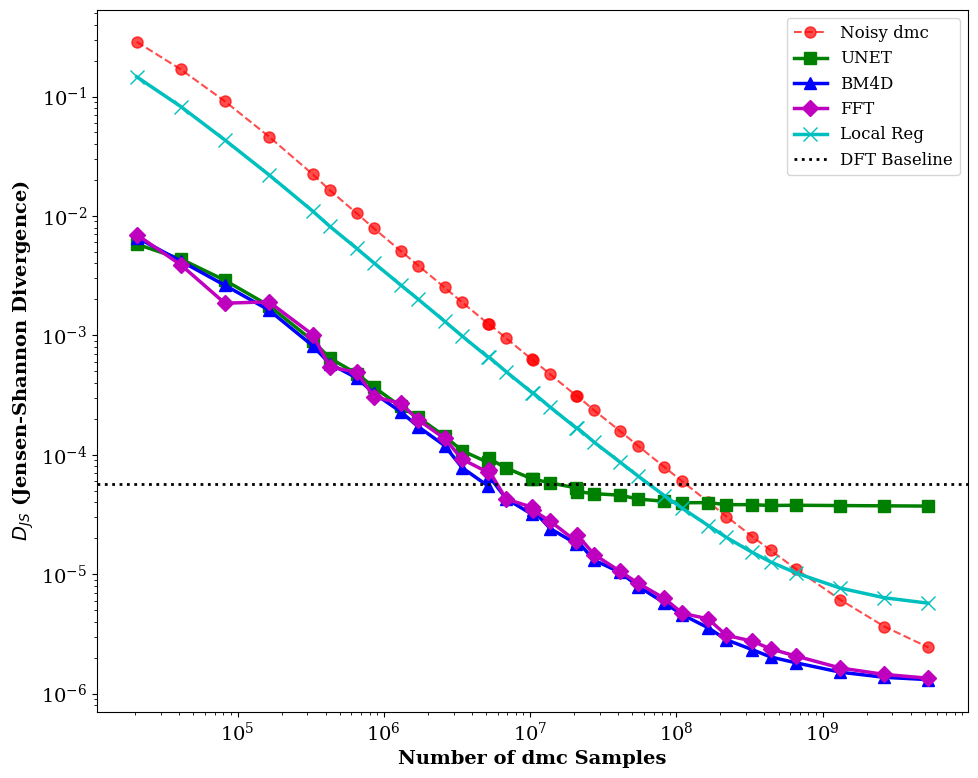

In [1]:
import os
import sys
import glob
import re
import logging  
import h5py
import numpy as np
import pandas as pd  # <-- Pandas is back!
import matplotlib.pyplot as plt
import tensorflow as tf
from bm4d import bm4d

# --- Suppress Matplotlib Debug Output ---
logging.getLogger('matplotlib').setLevel(logging.WARNING)
logging.getLogger('matplotlib.ticker').setLevel(logging.WARNING)

# --- Path Setups (Adjust as needed) ---
qmc_algo_path = os.path.abspath('/pscratch/sd/k/kberard/SCGSR/3D_VMC/Model_Train_dat/FFT_Jaron/qmc_algo_tools') 
dev = os.path.abspath('/pscratch/sd/k/kberard/SCGSR/3D_VMC/Model_Train_dat/FFT_Jaron/developer_tools') 
sys.path.insert(0, qmc_algo_path) 
sys.path.insert(0, dev) 
from qmc_algo_tools.density_denoise import DensityFourierFilterErrorCeil

# --- Definitions ---
def D_JS(p1, p2, tol=1e-16):
    p1 = p1 / np.sum(p1)
    p2 = p2 / np.sum(p2)
    pm = (p1 + p2) / 2
    p1_nonzero = np.abs(p1) > tol
    p2_nonzero = np.abs(p2) > tol
    p1  = np.abs(p1[p1_nonzero])
    pm1 = np.abs(pm[p1_nonzero])
    p2  = np.abs(p2[p2_nonzero])
    pm2 = np.abs(pm[p2_nonzero])
    d = .5 * ( (p1 * np.log(p1 / pm1)).sum() + (p2 * np.log(p2 / pm2)).sum() )
    d /= np.log(2)
    return d

def local_polyfit(y, deg=1, window=3):
    """Local polynomial regression method"""
    N = len(y)
    half = window // 2
    x = np.arange(N)
    y_out = np.zeros(N)

    for i in range(N):
        start = max(0, i - half)
        end   = min(N, i + half + 1)

        # local coordinates
        xi = x[start:end]
        yi = y[start:end]

        # fit polynomial to window
        coeffs = np.polyfit(xi, yi, deg)

        # predict at point i
        y_out[i] = np.polyval(coeffs, x[i])
    return y_out

# --- Transformation Functions (Needed for UNET) ---
def transform(density, density_ref, transform_type):
    if transform_type == 'residual_noise':
        return (density - density_ref) / np.sqrt(np.abs(density_ref))
    raise RuntimeError('bad transform type')

def inverse_transform(density_trans, density_ref, transform_type):
    if transform_type == 'residual_noise':
        return density_ref + np.sqrt(np.abs(density_ref)) * density_trans
    raise RuntimeError('bad transform type')

# --- 1. Load Reference Data ---
# dmc Reference
dmc_ref_path = '/pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_ref_mean.h5'
with h5py.File(dmc_ref_path, 'r') as file:
    ref_d = file['density'][:]
print(f"dmc Ref shape: {ref_d.shape}")

# DFT Data
dft_path = '/global/u2/k/kberard/SCGSR/Research/Diamond/Data/density_tot_ref.h5'
with h5py.File(dft_path, 'r') as file:
    dft_d = file['density'][:]


# --- 2. Setup Models and Directories ---
unet_model = tf.keras.models.load_model('/pscratch/sd/k/kberard/SCGSR/EDDA/Diamond/Density_Models/UNET_3D_Models/residual_denoiser_40M_Blob_NODFT.keras')

data_dir = '/pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/'
file_pattern = os.path.join(data_dir, "density_tot_dmc_mix_mean_*.h5")
files = glob.glob(file_pattern)

results = []
trans_type = 'residual_noise'

# Initialize FFT class ONCE before the loop
dm = DensityFourierFilterErrorCeil(density_ref=dft_d, filter_mode='augment')

print(f"Found {len(files)} files to process.")

# --- 3. Processing Loop ---
counter = 0
for fpath in files:
    print(fpath)
    counter += 1
    match = re.search(r'mean_(\d+)\.h5', os.path.basename(fpath))
    if not match: continue
    sample_count = int(match.group(1))
    print(f"Processing File {counter}/{len(files)} - Samples: {sample_count}")
    
    # Calculate Dynamic Sigma based on our calibration
    sigma_psd =1/np.sqrt(sample_count)
    
    with h5py.File(fpath, 'r') as f:
        test_d = np.array(f['density'])
    
    # ----------------------------------------------------
    # Method A: UNET (Uses residual transform)
    # ----------------------------------------------------
    input_reshaped = test_d[np.newaxis, ..., np.newaxis]
    dft_reshaped   = dft_d[np.newaxis, ..., np.newaxis]
    input_residual = transform(input_reshaped, dft_reshaped,'residual_noise')
    
    pred_residual = unet_model.predict(input_residual, verbose=0)
    denoised_raw = inverse_transform(pred_residual, dft_reshaped, 'residual_noise')
    denoised_unet = np.maximum(denoised_raw[0, ..., 0], 0.0)

    # ----------------------------------------------------
    # Method B: BM4D (Raw Density + Positive Clamp)
    # ----------------------------------------------------
    trans_d =transform(test_d, dft_d, trans_type)
    bm4d_raw = bm4d(trans_d, sigma_psd)
    bm4d_clean = inverse_transform(bm4d_raw, dft_d, trans_type)
    denoised_bm4d = np.maximum(bm4d_clean, 0.0)
    
    # ----------------------------------------------------
    # Method C: FFT (Raw Density)
    # ----------------------------------------------------
    denoised_fft = dm.denoise(test_d)

    # ----------------------------------------------------
    # Method D: Local Regression (Custom Function)
    # ----------------------------------------------------
    x_flat = test_d.ravel()
    
    y_smooth_lr = local_polyfit(x_flat, deg=2, window=5)
    lr_raw_3d = y_smooth_lr.reshape(test_d.shape) 
    denoised_lr = np.maximum(lr_raw_3d, 0.0)

    # ----------------------------------------------------
    # Calculate and Store Metrics
    # ----------------------------------------------------
    results.append({
        "Samples": sample_count,
        "Noisy_dmc": D_JS(test_d, ref_d),
        "UNET": D_JS(denoised_unet, ref_d),
        "BM4D": D_JS(denoised_bm4d, ref_d),
        "FFT": D_JS(denoised_fft, ref_d),
        "Local_Reg": D_JS(denoised_lr, ref_d)
    })

# --- 4. Data Export & Plotting ---
# Convert to DataFrame, sort, and save to CSV
df = pd.DataFrame(results).sort_values("Samples")
csv_filename = "denoising_performance_results_diamond.csv"
df.to_csv(csv_filename, index=False)
print(f"Results saved to {csv_filename}")

DFT_vs_DMC = D_JS(ref_d, dft_d)

# Plotting with Publication Settings
plt.rcParams.update({'font.size': 14, 'font.family': 'serif'})
fig, ax = plt.subplots(figsize=(10, 8))

# Plot all performance curves
ax.plot(df["Samples"], df["Noisy_dmc"], 'r--o', label='Noisy dmc', alpha=0.7, markersize=8)
ax.plot(df["Samples"], df["UNET"],      'g-s',  label='UNET', linewidth=2.5, markersize=8)
ax.plot(df["Samples"], df["BM4D"],      'b-^',  label='BM4D', linewidth=2.5, markersize=8)
ax.plot(df["Samples"], df["FFT"],       'm-D',  label='FFT', linewidth=2.5, markersize=8)
ax.plot(df["Samples"], df["Local_Reg"], 'c-x',  label='Local Reg', linewidth=2.5, markersize=10)

# Graph Formatting
ax.set_xscale('log')
ax.set_yscale('log')
ax.axhline(DFT_vs_DMC, color="black", linestyle=":", label="DFT Baseline", linewidth=2)

ax.set_xlabel('Number of dmc Samples', fontweight='bold')
ax.set_ylabel('$D_{JS}$ (Jensen-Shannon Divergence)', fontweight='bold')
ax.legend(frameon=True, loc='best', fontsize=12)

# Turn off the gridmarks completely
ax.grid(False)

plt.tight_layout()

# Save for Publication
plt.savefig("denoising_comparison_diamond_pub.png", dpi=300, bbox_inches='tight')
plt.savefig("denoising_comparison_diamond_pub.pdf", bbox_inches='tight')
plt.show()